Import librairies

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM


In [5]:
df = pd.read_csv(
    "vix_data.csv",
    skiprows=3,
    names=["Date", "Close", "High", "Low", "Open", "Volume"]
)
df["Date"] = pd.to_datetime(df["Date"])
#print(df.head())

In [24]:
model = GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=0)
X=df[["Close"]].values
model.fit(X)
states = model.predict(X)
log_likelihood = model.score(X)
print("Matrice de transition :")
print(model.transmat_)

print("Moyennes des régimes :")
print(model.means_)

print("Variances des régimes :")
print(model.covars_)

print("Log-likelihood :")
print(log_likelihood)

print(model.monitor_.converged)


Matrice de transition :
[[9.54324889e-001 3.07906718e-002 2.69784370e-065 1.48844393e-002]
 [2.40748723e-002 9.44661756e-001 3.01626286e-002 1.10074281e-003]
 [2.91831755e-026 2.57253838e-002 9.74274592e-001 2.41596424e-008]
 [3.75903513e-002 1.81597091e-109 1.41910593e-155 9.62409649e-001]]
Moyennes des régimes :
[[22.89644457]
 [16.60097845]
 [12.5415142 ]
 [38.18665235]]
Variances des régimes :
[[[  7.24708805]]

 [[  2.39935608]]

 [[  1.64691156]]

 [[128.02525445]]]
Log-likelihood :
-11689.68587469005
True


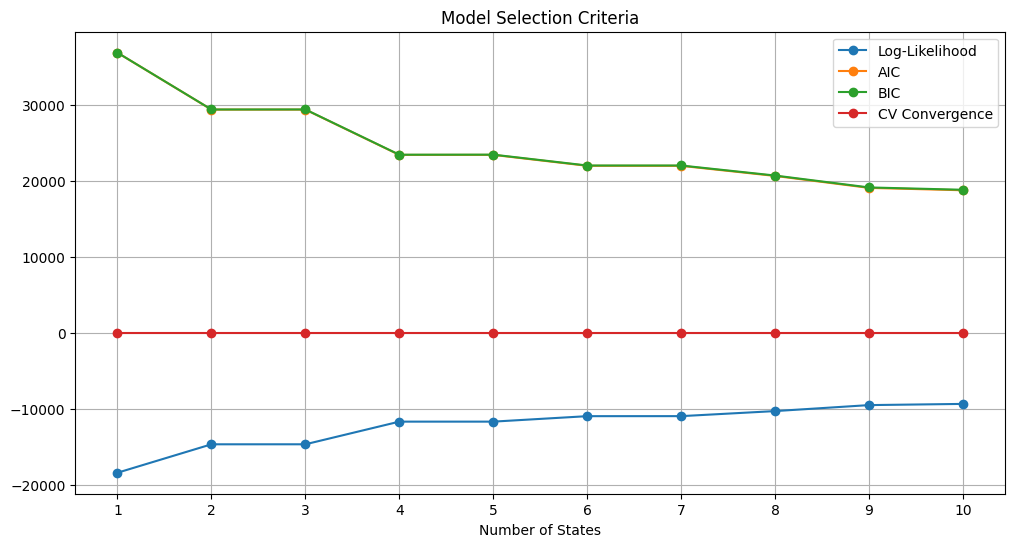

In [26]:
test_log_likelihood = [0] * 10
test_AIC = [0] * 10
test_BIC = [0] * 10
test_CV = [0] * 10
for i in range (1,11):
    model_test = GaussianHMM(n_components=i, covariance_type="diag", n_iter=100, random_state=0)
    model_test.fit(X)
    test_log_likelihood[i-1] = model_test.score(X)
    test_AIC[i-1] = -2 * test_log_likelihood[i-1] + 2 * i
    test_BIC[i-1] = -2 * test_log_likelihood[i-1] + i * np.log(len(X))
    test_CV[i-1] = model_test.monitor_.converged
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), test_log_likelihood, marker='o', label='Log-Likelihood')
plt.plot(range(1, 11), test_AIC, marker='o', label='AIC')
plt.plot(range(1, 11), test_BIC, marker='o', label='BIC')
plt.plot(range(1, 11), test_CV, marker='o', label='CV Convergence')
plt.xticks(range(1, 11))
plt.xlabel('Number of States')
plt.title('Model Selection Criteria')
plt.legend()
plt.grid()
plt.show()
